In [215]:
%%capture
pip install --pre pycen==0.1.0a4

import pycen
import pandas as pd
import geopandas as gpd
from pycen import explore, acquire
pycen.set_theme('default')

Note: On the city level, I'd use ACS1 estimates here because Berkeley is relatively large (100k+ residents) because it'd better capture impacts of infrastructure changes (whereas ACS5 estimates would average in data from the previous four years), but using ACS5 here because it may have a lower margin of error if our granularity is census tracts

## 5-Year ACS Estimate for 2024 (Berkeley)

In [216]:
# explore.browse(year=2024, dataset='acs5').show()

In [217]:
vars = {
    "B08006_014E": "bike_commuters", 
    "B08006_001E": "total_commuters"
}

In [218]:
%%capture
gdf = acquire.get_censhp(
    variables=vars,
    geography='tract',
    state='CA',
    county='Alameda',
    year=2024,
    dataset='acs5'
)

In [219]:
%%capture
bky_gdf = acquire.get_censhp(
    variables=vars,
    geography='tract',
    state='CA',
    place='Berkeley',
    year=2024,
    dataset='acs5'
)

In [220]:
# gdf = gdf.to_crs(bky_gdf.crs)
# bky_mask = bky_gdf.dissolve()
# bky_tracts = gpd.clip(gdf, bky_mask)
# bky_tracts["bike_pct"] = bky_tracts["bike_commuters"]/bky_tracts["total_commuters"]*100

In [221]:
bky_ids = set(bky_gdf["GEOID"])  
bky_tracts = gdf[gdf["GEOID"].isin(bky_ids)].copy()

bky_tracts["bike_pct"] = (
    bky_tracts["bike_commuters"] / bky_tracts["total_commuters"] * 100
)

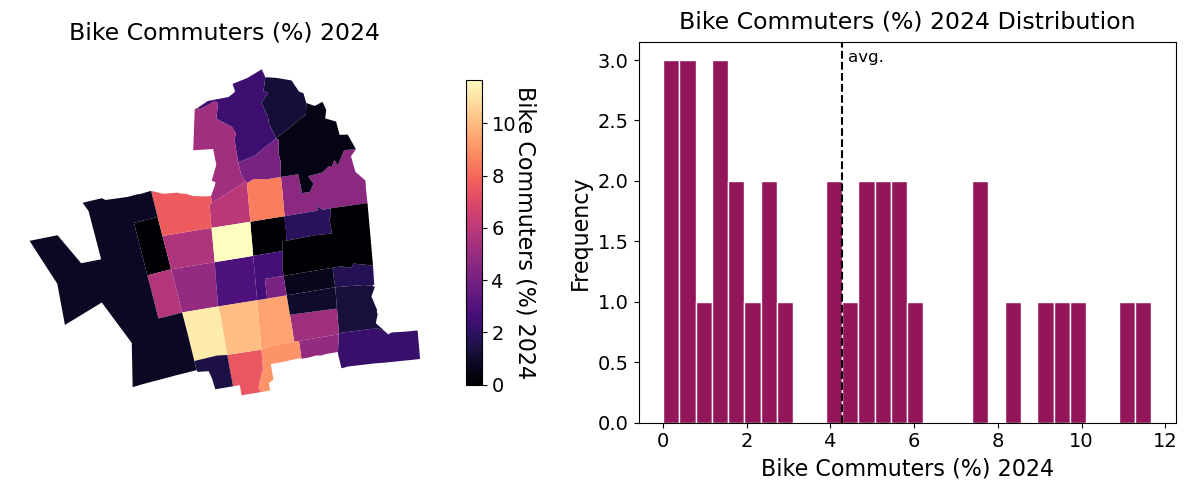

In [222]:
bky_tracts = bky_tracts.rename(
    columns={"bike_pct": "Bike Commuters (%) 2024"}
)
acquire.quick_viz(bky_tracts, "Bike Commuters (%) 2024") # quick viz for basic intuition

## 5-Year ACS Estimate for 2019 (Berkeley)

In [223]:
%%capture
gdf_19 = acquire.get_censhp(
    variables=vars,
    geography='tract',
    state='CA',
    county='Alameda',
    year=2019,
    dataset='acs5',
)

In [224]:
%%capture
bky_gdf_19 = acquire.get_censhp(
    variables=vars,
    geography='tract',
    state='CA',
    place='Berkeley',
    year=2019,
    dataset='acs5'
)

In [225]:
# gdf_19 = gdf_19.to_crs(bky_gdf_19.crs)
# bky_mask_19 = bky_gdf_19.dissolve()
# bky_tracts_19 = gpd.clip(gdf_19, bky_mask_19)

In [226]:
bky_ids_19 = set(bky_gdf_19["GEOID"])  
bky_tracts_19 = gdf_19[gdf_19["GEOID"].isin(bky_ids)].copy()

bky_tracts_19["bike_pct"] = (
    bky_tracts_19["bike_commuters"] / bky_tracts_19["total_commuters"] * 100
)

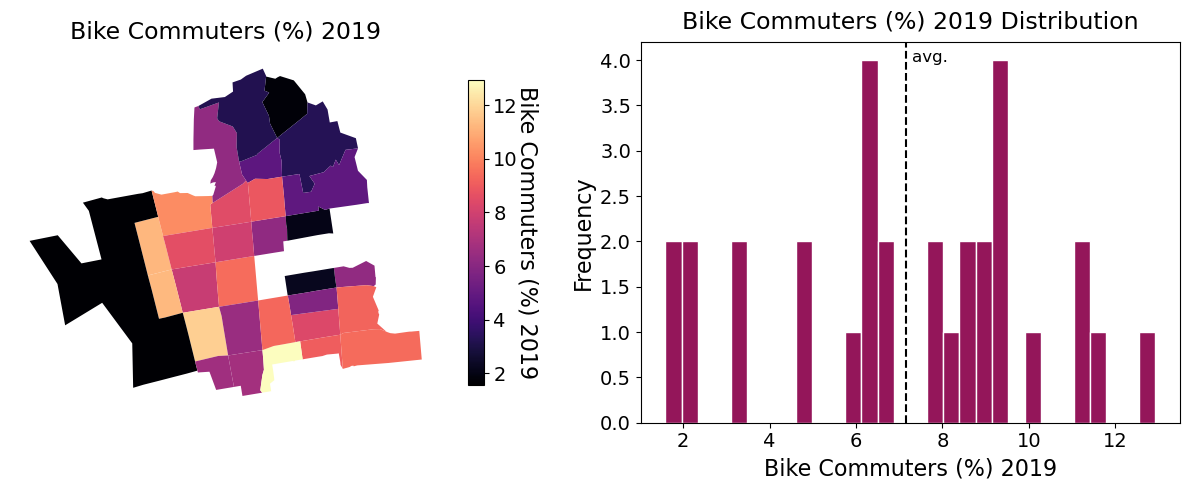

In [227]:
bky_tracts_19["bike_pct"] = bky_tracts_19["bike_commuters"]/bky_tracts_19["total_commuters"]*100

bky_tracts_19 = bky_tracts_19.rename(
    columns={"bike_pct": "Bike Commuters (%) 2019"}
)
acquire.quick_viz(bky_tracts_19, "Bike Commuters (%) 2019") # quick viz for basic intuition

## % Change in Ridership

In [228]:
bky_tracts = bky_tracts.rename(
    columns={"Bike Commuters (%) 2024": "bike_pct_2024"}
)

bky_tracts_19 = bky_tracts_19.rename(
    columns={"Bike Commuters (%) 2019": "bike_pct_2019"}
)

merged = bky_tracts.merge(
    bky_tracts_19[["GEOID", "bike_pct_2019"]],
    on="GEOID"
)

In [229]:
merged["pct_change"] = (
    (merged["bike_pct_2024"] - merged["bike_pct_2019"]) /
    merged["bike_pct_2019"]
) * 100

merged = merged[['geometry', 'bike_pct_2024', 'bike_pct_2019', 'pct_change']]

Text(0.5, 1.0, 'Change in Bike Commuting (2019–2024)')

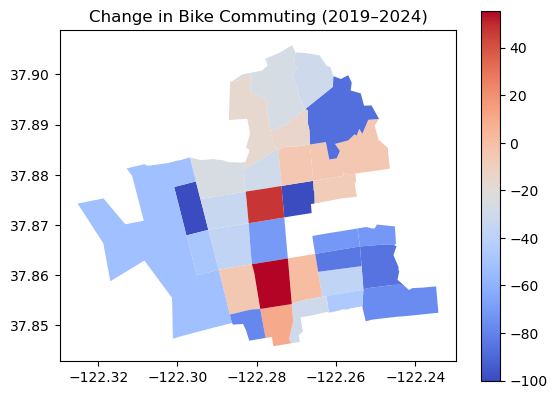

In [230]:
import matplotlib.pyplot as plt

merged.plot(column="pct_change", cmap="coolwarm", legend=True)
plt.title("Change in Bike Commuting (2019–2024)")